# Run 5: CORSIKA Neutrino Analysis

This notebook analyze the neutrino generated from CORSIKA 8 shower outputs events with run3_Corsika_EventGenerator.ipynb.


## 1. Libraries and Parameters

This section loads the analysis dependencies, campaign paths, primary-species metadata, and helper functions required by the neutrino diagnostics.


In [1]:
from __future__ import annotations
%matplotlib inline

from dataclasses import dataclass
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)


In [2]:
PATH_CORSIKA_ROOT = "/home/juan/hep/opt/corsika8-install"
RUN = "run_3"

DEFAULT_OUTPUT_ROOT = Path(r"/mnt/v/output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))
OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_CORSIKA_ROOT = Path(OUTPUT_DATA_ROOT / "corsika")
OUTPUT_CORSIKA_ROOT.mkdir(parents=True, exist_ok=True)

# Backward-compatible aliases used by the original notebook code.
PATH_OUTPUT_ROOT = OUTPUT_ROOT
PATH_OUTPUT_CORSIKA = OUTPUT_CORSIKA_ROOT
PATH_OUTPUT_CORSIKA_GENERATOR = Path(OUTPUT_CORSIKA_ROOT / "generator")
PATH_OUTPUT_CORSIKA_GENERATOR.mkdir(parents=True, exist_ok=True)

PATH_OUTPUT_RUN = Path(PATH_OUTPUT_CORSIKA_GENERATOR / RUN)
PATH_CRMODEL_FILE = Path(PATH_OUTPUT_RUN / "cosmic_ray_model.h5")
PATH_PRIMARIES_FILE = Path(PATH_OUTPUT_RUN / "primaries_000003.csv")
PATH_MANIFEST_FILE = Path(PATH_OUTPUT_RUN / "manifest.csv")
PATH_DATASET_NEUTRINO_FILE = Path(PATH_OUTPUT_RUN / "dataset_neutrino_test.h5")
PATH_OUTPUT_RUN.mkdir(parents=True, exist_ok=True)

print(" Configured workflow paths:\n", "=" * 80)
print(" - PATH_CORSIKA_ROOT = ", PATH_CORSIKA_ROOT)
print(" - DEFAULT_OUTPUT_ROOT = ", DEFAULT_OUTPUT_ROOT)
print(" - OUTPUT_ROOT = ", OUTPUT_ROOT)
print(" - OUTPUT_DATA_ROOT = ", OUTPUT_DATA_ROOT)
print(" - OUTPUT_CORSIKA_ROOT = ", OUTPUT_CORSIKA_ROOT)
print(" - RUN = ", RUN, "\n")

print(" Output paths:\n", "=" * 80)
print(" - PATH_OUTPUT_RUN       = ", PATH_OUTPUT_RUN)
print(" - PATH_CRMODEL_FILE     = ", PATH_CRMODEL_FILE)
print(" - PATH_PRIMARIES_FILE   = ", PATH_PRIMARIES_FILE)
print(" - PATH_MANIFEST_FILE    = ", PATH_MANIFEST_FILE)
print(" - PATH_DATASET_NEUTRINO_FILE  = ", PATH_DATASET_NEUTRINO_FILE)


 Configured workflow paths:
 - PATH_CORSIKA_ROOT =  /home/juan/hep/opt/corsika8-install
 - DEFAULT_OUTPUT_ROOT =  /mnt/v/output
 - OUTPUT_ROOT =  /mnt/v/output
 - OUTPUT_DATA_ROOT =  /mnt/v/output/data
 - OUTPUT_CORSIKA_ROOT =  /mnt/v/output/data/corsika
 - RUN =  run_3 

 Output paths:
 - PATH_OUTPUT_RUN       =  /mnt/v/output/data/corsika/generator/run_3
 - PATH_CRMODEL_FILE     =  /mnt/v/output/data/corsika/generator/run_3/cosmic_ray_model.h5
 - PATH_PRIMARIES_FILE   =  /mnt/v/output/data/corsika/generator/run_3/primaries_000003.csv
 - PATH_MANIFEST_FILE    =  /mnt/v/output/data/corsika/generator/run_3/manifest.csv
 - PATH_DATASET_NEUTRINO_FILE  =  /mnt/v/output/data/corsika/generator/run_3/dataset_neutrino_test.h5


In [3]:

@dataclass(frozen=True)
class Config:
    """Minimal paths required for Run 3 analysis notebooks."""
    output_root: Path = Path(PATH_OUTPUT_RUN)
    manifest_path: Path = Path(PATH_MANIFEST_FILE)
    corsika_root: Path = Path(PATH_CORSIKA_ROOT)


CONFIG = Config(
    output_root=Path(PATH_OUTPUT_RUN),
    manifest_path=Path(PATH_MANIFEST_FILE),
    corsika_root=Path(PATH_CORSIKA_ROOT),
)

print("Run 3 analysis paths")
print("-" * 72)
print(f"output_root  : {CONFIG.output_root}")
print(f"manifest_path: {CONFIG.manifest_path}")
print(f"corsika_root : {CONFIG.corsika_root}")
print(f"\nManifest File exists: {CONFIG.manifest_path.exists()}")


Run 3 analysis paths
------------------------------------------------------------------------
output_root  : /mnt/v/output/data/corsika/generator/run_3
manifest_path: /mnt/v/output/data/corsika/generator/run_3/manifest.csv
corsika_root : /home/juan/hep/opt/corsika8-install

Manifest File exists: True


In [4]:
PRIMARY_SPECIES: dict[int, dict[str, object]] = {
    14:   {"mnemonic": "p",    "name": "proton",      "Z": 1,  "A": 1,  "pdg": 2212},
    402:  {"mnemonic": "He",   "name": "helium",      "Z": 2,  "A": 4,  "pdg": 0},
    1206: {"mnemonic": "C",    "name": "carbon",      "Z": 6,  "A": 12, "pdg": 0},
    1407: {"mnemonic": "N",    "name": "nitrogen",    "Z": 7,  "A": 14, "pdg": 0},
    1608: {"mnemonic": "O",    "name": "oxygen",      "Z": 8,  "A": 16, "pdg": 0},
    2412: {"mnemonic": "Mg",   "name": "magnesium",   "Z": 12, "A": 24, "pdg": 0},
    2613: {"mnemonic": "Al",   "name": "aluminium",   "Z": 13, "A": 26, "pdg": 0},
    2814: {"mnemonic": "Si",   "name": "silicon",     "Z": 14, "A": 28, "pdg": 0},
    5025: {"mnemonic": "Mn",   "name": "manganese",   "Z": 25, "A": 50, "pdg": 0},
    5426: {"mnemonic": "Fe54", "name": "iron-54",     "Z": 26, "A": 54, "pdg": 0},
    5626: {"mnemonic": "Fe56", "name": "iron-56",     "Z": 26, "A": 56, "pdg": 0},
    5427: {"mnemonic": "Co54", "name": "cobalt-54",   "Z": 27, "A": 54, "pdg": 0},
}


In [5]:
       
def path_from_output(path: str | Path) -> Path:
    """Resolve a manifest/metadata path relative to OUTPUT_CORSIKA_ROOT."""
    path = Path(path)
    return path if path.is_absolute() else PATH_OUTPUT_CORSIKA / path
    
def load_primary_metadata_for_manifest(manifest: pd.DataFrame, output_root: Path) -> pd.DataFrame:
    """Load per-event primary metadata and join it with the execution manifest."""
    metadata_rows = []
    for event_id in manifest["event_id"].astype(int):
        metadata_path = output_root / "_primaries" / f"event_{event_id:08d}.csv"
        if not metadata_path.exists():
            continue
        row = pd.read_csv(metadata_path).iloc[0].to_dict()
        metadata_rows.append(row)

    metadata = pd.DataFrame(metadata_rows)
    if metadata.empty:
        return manifest.copy()

    metadata["event_id"] = metadata["event_id"].astype(int)
    joined = manifest.merge(metadata, on="event_id", how="left", suffixes=("", "_primary"))
    return joined


In [6]:
NEUTRINO_PRODUCTION_PDG = {
    12: "e", -12: "e",
    14: "mu", -14: "mu",
    16: "tau", -16: "tau",
}


def summarize_produced_neutrinos(event_dir: Path) -> dict[str, int]:
    """Count neutrinos produced by the TPEANUTS writer for one event."""
    path = event_dir / "tpeanuts" / "neutrino_production.parquet"
    counts = {"neutrino_total": 0, "neutrino_e": 0, "neutrino_mu": 0, "neutrino_tau": 0}
    if not path.exists():
        return counts
    neutrinos = pd.read_parquet(path, columns=["neutrino_pdg"])
    counts["neutrino_total"] = int(len(neutrinos))
    flavors = neutrinos["neutrino_pdg"].map(NEUTRINO_PRODUCTION_PDG)
    counts["neutrino_e"] = int((flavors == "e").sum())
    counts["neutrino_mu"] = int((flavors == "mu").sum())
    counts["neutrino_tau"] = int((flavors == "tau").sum())
    return counts


In [7]:
manifest = pd.read_csv(CONFIG.manifest_path)
print(f"Manifest rows: {len(manifest):,}")
display(manifest.tail())


Manifest rows: 3,762


,event_id,status,returncode,output_dir,stdout_log,stderr_log,elapsed_seconds,command,corsika_id,primary_mnemonic,primary_name,Z,A,pdg,E0_GeV,theta0_deg,phi0_deg,observation_level_m,primary_weight,p_real,q_sim,importance_ratio,neutrino_total,neutrino_e,neutrino_mu,neutrino_tau
3757,7783,done,0,generator/run_3/event_00007783,generator/run_3/_logs/event_00007783/stdout.log,generator/run_3/_logs/event_00007783/stderr.log,713.527195,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 6 -A 12 -E 52214.9138109 -z 59.5485371735 -a 311.621796665 --observation-level 0 --track-neutrinos -N 1 -s 7825 --verbosit...,1206,C,carbon,6,12,0,52214.913811,59.548537,311.621797,71290.130499,1.397174e-08,7.196084e-15,1.900685e-11,0.000379,5967,1654,4313,0
3758,7774,done,0,generator/run_3/event_00007774,generator/run_3/_logs/event_00007774/stdout.log,generator/run_3/_logs/event_00007774/stderr.log,2315.762127,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 14 -A 28 -E 140617.870344 -z 47.7727990688 -a 280.401694245 --observation-level 0 --track-neutrinos -N 1 -s 7816 --verbosi...,2814,Si,silicon,14,28,0,140617.870344,47.772799,280.401694,72029.507602,1.291120e-09,5.712754e-16,1.632840e-11,0.000035,15483,4237,11246,0
3759,7798,done,0,generator/run_3/event_00007798,generator/run_3/_logs/event_00007798/stdout.log,generator/run_3/_logs/event_00007798/stderr.log,14.790376,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 8 -A 16 -E 1123.05004727 -z 17.5389263169 -a 221.996755051 --observation-level 0 --track-neutrinos -N 1 -s 7840 --verbosit...,1608,O,oxygen,8,16,0,1123.050047,17.538926,221.996755,97942.926388,1.204824e-05,2.135178e-12,6.539963e-12,0.326482,0,0,0,0
3760,7800,done,0,generator/run_3/event_00007800,generator/run_3/_logs/event_00007800/stdout.log,generator/run_3/_logs/event_00007800/stderr.log,16.088786,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 6 -A 12 -E 759.4438413 -z 34.4132188439 -a 180.718506349 --observation-level 0 --track-neutrinos -N 1 -s 7842 --verbosity ...,1206,C,carbon,6,12,0,759.443841,34.413219,180.718506,6083.155561,1.584602e-05,5.294941e-12,1.233121e-11,0.429393,0,0,0,0
3761,7728,timeout,-124,generator/run_3/event_00007728,generator/run_3/_logs/event_00007728/stdout.log,generator/run_3/_logs/event_00007728/stderr.log,3600.057027,home/juan/hep/opt/corsika8-install/bin/c8_tpeanuts -Z 13 -A 26 -E 397509.322246 -z 82.6949467488 -a 230.307840519 --observation-level 0 --track-neutrinos -N 1 -s 7770 --verbosi...,2613,Al,aluminium,13,26,0,397509.322246,82.694947,230.307841,9539.005484,5.223318e-11,3.085730e-17,2.180099e-11,0.000001,0,0,0,0


## 2. Successful Event Energy-Extreme Comparison

This section compares the five lowest-energy and five highest-energy successful events, focusing on runtime and secondary-neutrino production recorded in `particles.parquet`.


,energy_group,event_id,status,E0_GeV,theta0_deg,observation_level_m,elapsed_seconds,primary_weight,total_particles,neutrino_count,neutrino_weight_sum,max_neutrino_energy_GeV,sum_neutrino_energy_GeV,neutrino_flavors
0,lowest_5,3947,done,103.654343,74.684571,32647.831613,10.814853,2.209822e-03,1,0,0.0,NaN,0.000000,
1,lowest_5,6245,done,103.896079,51.253828,83814.812194,10.358148,2.209822e-03,1,0,0.0,NaN,0.000000,
2,lowest_5,5481,done,105.602076,41.538410,53769.967795,14.994889,3.867556e-03,14,5,5.0,7.566126,15.284034,anti_nu_mu:2; nu_mu:3
3,lowest_5,6119,done,106.127321,76.595447,62025.806600,15.773849,3.777347e-03,4,4,4.0,2.754091,7.874478,anti_nu_mu:1; nu_mu:3
4,lowest_5,1157,done,107.274864,37.593376,46650.611874,11.303536,3.689242e-03,10,6,6.0,4.407386,14.194021,anti_nu_mu:4; nu_mu:2
5,highest_5,808,done,302529.535487,78.934209,33898.641513,3467.247592,6.448901e-10,11437,7048,7048.0,1691.814453,62471.753906,anti_nu_e:953; anti_nu_mu:2525; nu_e:984; nu_mu:2586
6,highest_5,298,done,278404.560394,81.528528,82179.746552,3420.342268,3.427926e-10,11792,7406,7406.0,733.611877,59772.078125,anti_nu_e:1064; anti_nu_mu:2597; nu_e:1028; nu_mu:2717
7,highest_5,1306,done,267612.941373,85.231570,10203.343515,3507.356923,1.015127e-10,9333,5644,5644.0,1242.927856,56383.492188,anti_nu_e:619; anti_nu_mu:2158; nu_e:948; nu_mu:1919
8,highest_5,4742,done,264887.989692,82.403927,42113.705960,3283.003185,3.641545e-10,10840,6764,6764.0,989.219910,60669.816406,anti_nu_e:941; anti_nu_mu:2427; nu_e:1001; nu_mu:2395
9,highest_5,209,done,261981.377754,66.252853,594.954138,3144.253101,8.087125e-10,10477,5706,5706.0,1078.089722,40718.578125,anti_nu_e:663; anti_nu_mu:2148; nu_e:668; nu_mu:2227


Group-level comparison:


,events,mean_primary_energy_GeV,min_primary_energy_GeV,max_primary_energy_GeV,mean_runtime_s,max_runtime_s,total_neutrinos,mean_neutrinos_per_event,total_neutrino_weight,max_secondary_neutrino_energy_GeV
energy_group,,,,,,,,,,
highest_5,5,275083.280940,261981.377754,302529.535487,3364.440614,3507.356923,32568,6513.6,32568.0,1691.814453
lowest_5,5,105.310937,103.654343,107.274864,12.649055,15.773849,15,3.0,15.0,7.566126


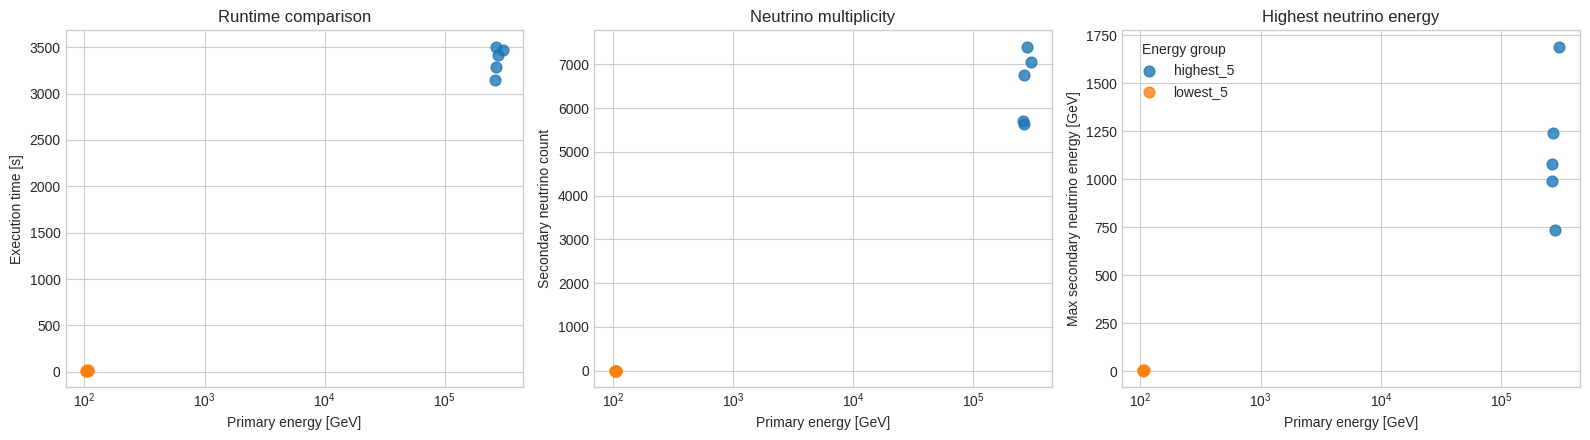

In [8]:
NEUTRINO_PDG_LABELS = {
    12: "nu_e",
    -12: "anti_nu_e",
    14: "nu_mu",
    -14: "anti_nu_mu",
    16: "nu_tau",
    -16: "anti_nu_tau",
}


def load_successful_event_table(manifest: pd.DataFrame, output_root: Path) -> pd.DataFrame:
    """Join successful manifest rows with primary metadata."""

    successful = manifest[manifest["status"].isin(["done", "skipped_done"])].copy()
    rows = []
    for event_id in successful["event_id"].astype(int):
        metadata_path = output_root / "_primaries" / f"event_{event_id:08d}.csv"
        if metadata_path.exists():
            row = pd.read_csv(metadata_path).iloc[0].to_dict()
            rows.append(row)

    metadata = pd.DataFrame(rows)
    if metadata.empty:
        return successful

    metadata["event_id"] = metadata["event_id"].astype(int)
    return successful.merge(metadata, on="event_id", how="inner", suffixes=("", "_primary"))


def summarize_neutrino_content(event_dir: Path) -> dict[str, object]:
    """Read particles.parquet and summarize secondary neutrinos."""

    particles_path = event_dir / "particles" / "particles.parquet"
    if not particles_path.exists():
        return {
            "particles_file": str(particles_path),
            "particles_file_exists": False,
            "total_particles": 0,
            "neutrino_count": 0,
            "neutrino_weight_sum": 0.0,
            "max_neutrino_energy_GeV": np.nan,
            "sum_neutrino_energy_GeV": 0.0,
            "neutrino_flavors": "",
        }

    particles = pd.read_parquet(particles_path)
    neutrinos = particles[particles["pdg"].isin(NEUTRINO_PDG_LABELS)].copy()
    if neutrinos.empty:
        return {
            "particles_file": str(particles_path),
            "particles_file_exists": True,
            "total_particles": len(particles),
            "neutrino_count": 0,
            "neutrino_weight_sum": 0.0,
            "max_neutrino_energy_GeV": np.nan,
            "sum_neutrino_energy_GeV": 0.0,
            "neutrino_flavors": "",
        }

    flavor_counts = neutrinos["pdg"].map(NEUTRINO_PDG_LABELS).value_counts().sort_index()
    return {
        "particles_file": str(particles_path),
        "particles_file_exists": True,
        "total_particles": len(particles),
        "neutrino_count": len(neutrinos),
        "neutrino_weight_sum": float(neutrinos["weight"].sum()),
        "max_neutrino_energy_GeV": float(neutrinos["kinetic_energy"].max()),
        "sum_neutrino_energy_GeV": float(neutrinos["kinetic_energy"].sum()),
        "neutrino_flavors": "; ".join(f"{name}:{count}" for name, count in flavor_counts.items()),
    }


successful_events = load_successful_event_table(manifest, CONFIG.output_root)

if successful_events.empty or "E0_GeV" not in successful_events:
    print("No successful events with primary metadata were found.")
else:
    lowest_energy_events = successful_events.sort_values("E0_GeV", ascending=True).head(5).copy()
    highest_energy_events = successful_events.sort_values("E0_GeV", ascending=False).head(5).copy()
    comparison_events = pd.concat(
        [
            lowest_energy_events.assign(energy_group="lowest_5"),
            highest_energy_events.assign(energy_group="highest_5"),
        ],
        ignore_index=True,
    )

    neutrino_summaries = []
    for row in comparison_events.itertuples(index=False):
        summary = summarize_neutrino_content(path_from_output(row.output_dir))
        summary["event_id"] = int(row.event_id)
        neutrino_summaries.append(summary)

    neutrino_summary_table = pd.DataFrame(neutrino_summaries)
    comparison_table = comparison_events.merge(neutrino_summary_table, on="event_id", how="left")

    columns = [
        "energy_group",
        "event_id",
        "status",
        "E0_GeV",
        "theta0_deg",
        "observation_level_m",
        "elapsed_seconds",
        "primary_weight",
        "total_particles",
        "neutrino_count",
        "neutrino_weight_sum",
        "max_neutrino_energy_GeV",
        "sum_neutrino_energy_GeV",
        "neutrino_flavors",
    ]
    display(comparison_table[columns])

    print("Group-level comparison:")
    display(
        comparison_table.groupby("energy_group").agg(
            events=("event_id", "count"),
            mean_primary_energy_GeV=("E0_GeV", "mean"),
            min_primary_energy_GeV=("E0_GeV", "min"),
            max_primary_energy_GeV=("E0_GeV", "max"),
            mean_runtime_s=("elapsed_seconds", "mean"),
            max_runtime_s=("elapsed_seconds", "max"),
            total_neutrinos=("neutrino_count", "sum"),
            mean_neutrinos_per_event=("neutrino_count", "mean"),
            total_neutrino_weight=("neutrino_weight_sum", "sum"),
            max_secondary_neutrino_energy_GeV=("max_neutrino_energy_GeV", "max"),
        )
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for group_name, group_data in comparison_table.groupby("energy_group"):
        axes[0].scatter(group_data["E0_GeV"], group_data["elapsed_seconds"], label=group_name, s=60, alpha=0.8)
        axes[1].scatter(group_data["E0_GeV"], group_data["neutrino_count"], label=group_name, s=60, alpha=0.8)
        axes[2].scatter(group_data["E0_GeV"], group_data["max_neutrino_energy_GeV"], label=group_name, s=60, alpha=0.8)

    axes[0].set_xscale("log")
    axes[0].set_xlabel("Primary energy [GeV]")
    axes[0].set_ylabel("Execution time [s]")
    axes[0].set_title("Runtime comparison")

    axes[1].set_xscale("log")
    axes[1].set_xlabel("Primary energy [GeV]")
    axes[1].set_ylabel("Secondary neutrino count")
    axes[1].set_title("Neutrino multiplicity")

    axes[2].set_xscale("log")
    axes[2].set_xlabel("Primary energy [GeV]")
    axes[2].set_ylabel("Max secondary neutrino energy [GeV]")
    axes[2].set_title("Highest neutrino energy")

    axes[2].legend(title="Energy group")
    plt.tight_layout()
    plt.show()

## 3. TPEANUTS Neutrino Production Analysis

This section analyzes neutrinos produced by `c8_tpeanuts` for the first `N=1000` successful manifest rows. It summarizes neutrino production versus primary properties, then selects the event with the largest produced-neutrino count and inspects its production and impact distributions.

The standard CORSIKA particle table contains `pdg`, `kinetic_energy`, direction cosines `nx`, `ny`, `nz`, and particle `weight`. For neutrinos, the kinetic energy is treated as $E_\nu$ because neutrino masses are negligible for this application.

The downward-going neutrino zenith angle is computed as:

$$
\theta_\nu = \arccos(-n_z).
$$



Successful events analyzed: 2870 / requested 40000


,event_id,primary_mnemonic,E0_GeV,theta0_deg,observation_level_m,neutrino_total,neutrino_e,neutrino_mu,neutrino_tau
0,25,C,704.793931,11.993540,59039.710097,0,0,0,0
1,4,He,163.421266,31.972820,44371.038114,0,0,0,0
2,26,Mg,644.050185,39.159350,78700.633434,0,0,0,0
3,30,Mn,1425.428845,50.768516,2706.765234,0,0,0,0
4,34,Mg,982.923705,54.127337,63654.951325,0,0,0,0


Neutrino count summary


,neutrino_total,neutrino_e,neutrino_mu,neutrino_tau
count,2870.000000,2870.000000,2870.000000,2870.0
mean,3344.930314,948.987805,2395.942509,0.0
std,4620.395779,1302.785565,3330.229892,0.0
min,0.000000,0.000000,0.000000,0.0
25%,132.000000,39.000000,94.250000,0.0
50%,1423.000000,410.500000,1010.000000,0.0
75%,4471.750000,1286.750000,3185.250000,0.0
max,27693.000000,7825.000000,19868.000000,0.0


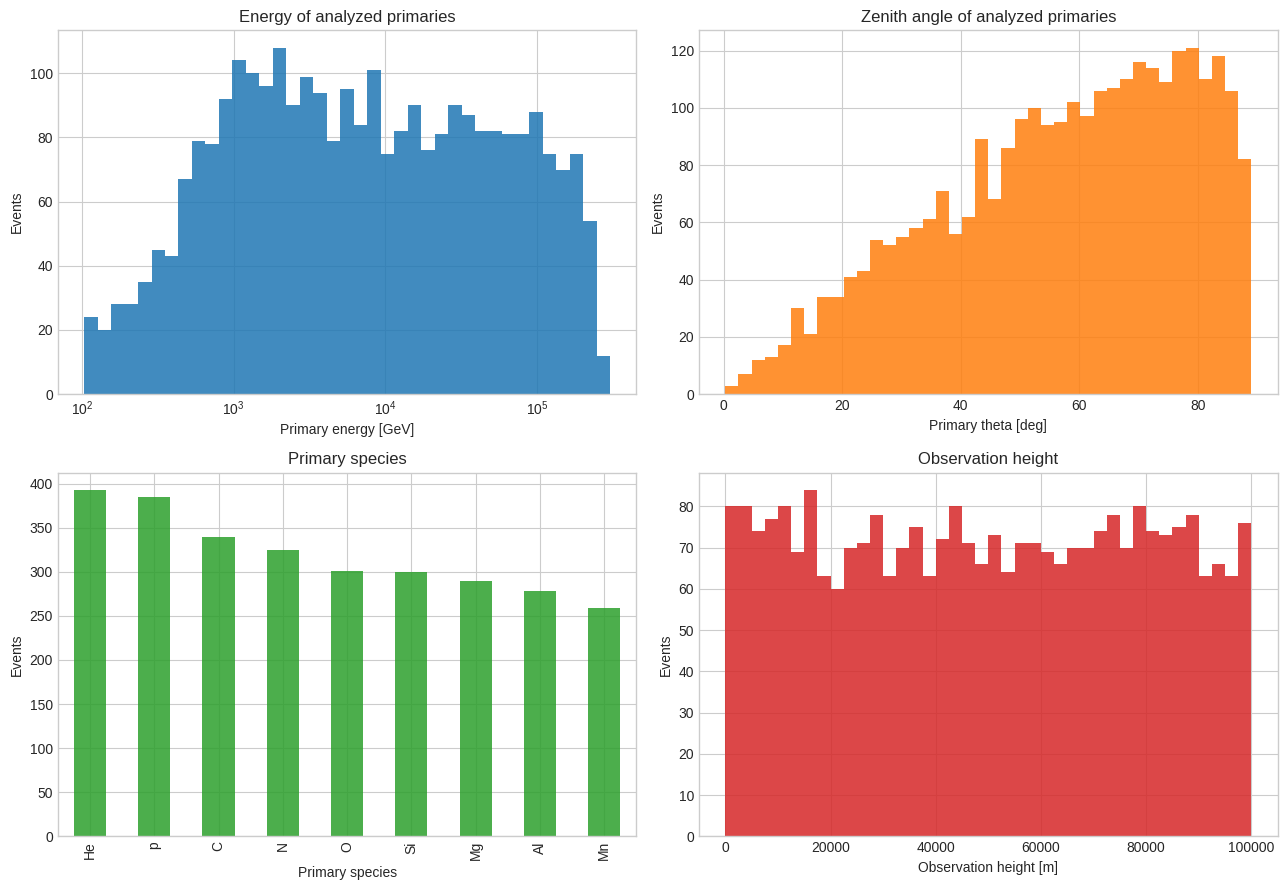

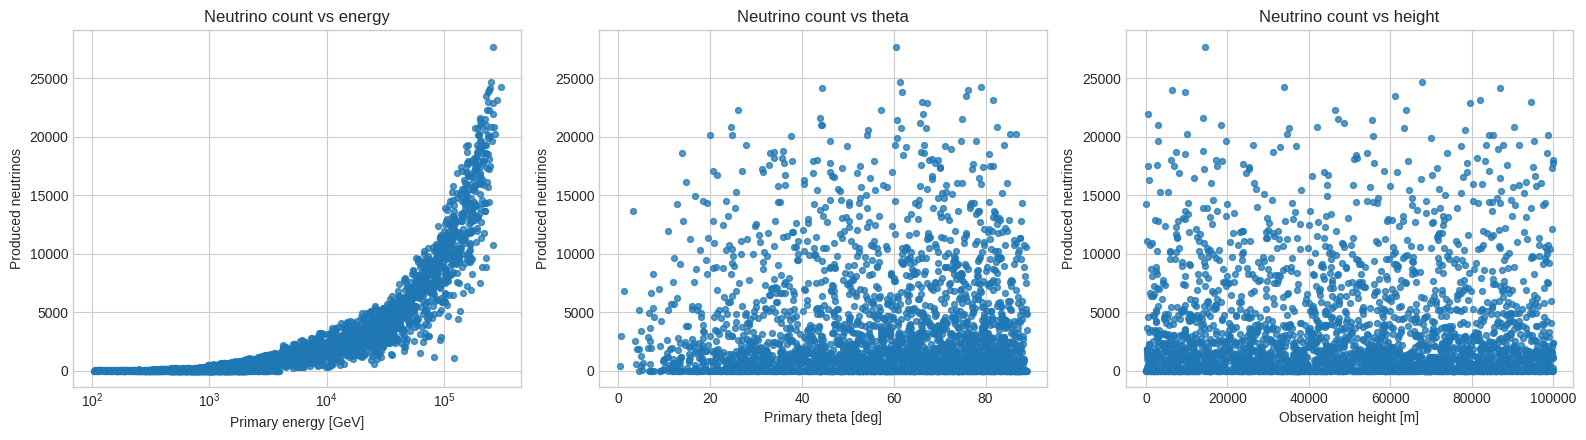

Event with maximum produced-neutrino count
------------------------------------------------------------------------
event_id:           300
primary:            Mn (manganese)
E0_GeV:             2.604440e+05
theta0_deg:         60.555
observation h [m]:  14414.4
produced neutrinos: 27693
observed neutrinos: 6856


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


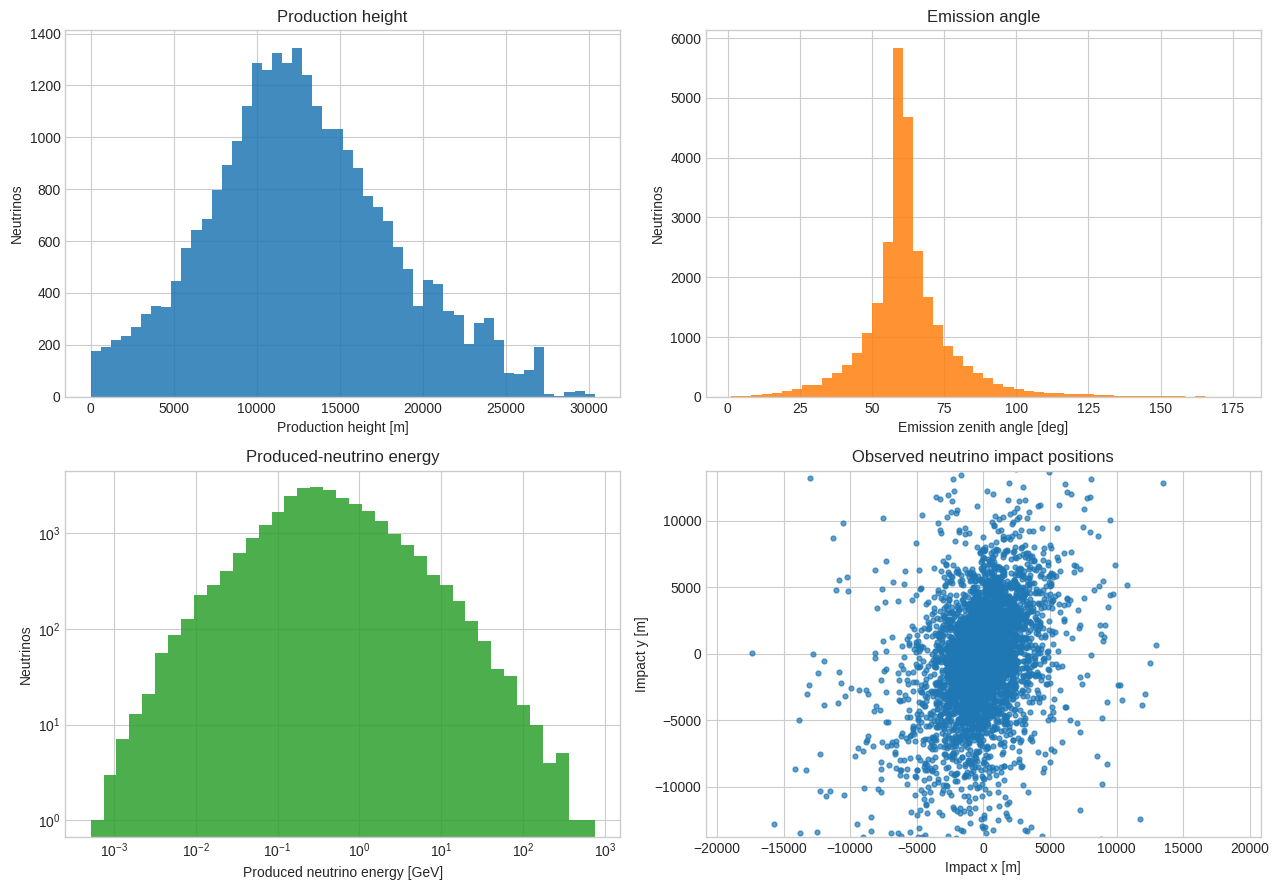

In [9]:
N_ANALYSIS = 40000


def load_tpeanuts_neutrinos(event_dir: Path) -> pd.DataFrame:
    """Load TPEANUTS neutrino-production rows for one event."""
    path = event_dir / "tpeanuts" / "neutrino_production.parquet"
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

 
def load_observation_neutrinos(event_dir: Path) -> pd.DataFrame:
    """Load observed neutrino rows at the observation plane for one event."""
    path = event_dir / "particles" / "particles.parquet"
    if not path.exists():
        return pd.DataFrame()
    particles = pd.read_parquet(path)
    return particles[particles["pdg"].abs().isin([12, 14, 16])].copy()


manifest_latest = pd.read_csv(CONFIG.manifest_path).drop_duplicates("event_id", keep="last")
analysis_events = manifest_latest[manifest_latest["status"].isin(["done", "skipped_done"])].head(N_ANALYSIS).copy()
print(f"Successful events analyzed: {len(analysis_events)} / requested {N_ANALYSIS}")

if analysis_events.empty:
    print("No successful events available for TPEANUTS neutrino analysis.")
else:
    if "primary_mnemonic" not in analysis_events or "E0_GeV" not in analysis_events:
        analysis_events = load_primary_metadata_for_manifest(analysis_events, CONFIG.output_root)
    if "primary_mnemonic" not in analysis_events and "corsika_id" in analysis_events:
        analysis_events["primary_mnemonic"] = analysis_events["corsika_id"].map(lambda cid: PRIMARY_SPECIES.get(int(cid), {"mnemonic": str(cid)})["mnemonic"])
    if "primary_name" not in analysis_events and "corsika_id" in analysis_events:
        analysis_events["primary_name"] = analysis_events["corsika_id"].map(lambda cid: PRIMARY_SPECIES.get(int(cid), {"name": "unknown"})["name"])
    for column in ["neutrino_total", "neutrino_e", "neutrino_mu", "neutrino_tau"]:
        if column not in analysis_events:
            analysis_events[column] = 0
    for idx, row in analysis_events.iterrows():
        counts = summarize_produced_neutrinos(path_from_output(row["output_dir"]))
        for column, value in counts.items():
            if pd.isna(analysis_events.at[idx, column]) or int(analysis_events.at[idx, column]) == 0:
                analysis_events.at[idx, column] = value
    display(analysis_events[["event_id", "primary_mnemonic", "E0_GeV", "theta0_deg", "observation_level_m", "neutrino_total", "neutrino_e", "neutrino_mu", "neutrino_tau"]].head())
    print("Neutrino count summary")
    display(analysis_events[["neutrino_total", "neutrino_e", "neutrino_mu", "neutrino_tau"]].describe())

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    energy_bins = np.logspace(np.log10(analysis_events["E0_GeV"].dropna().min()), np.log10(analysis_events["E0_GeV"].dropna().max()), 40)
    axes[0, 0].hist(analysis_events["E0_GeV"].dropna(), bins=energy_bins, color="tab:blue", alpha=0.85)
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_xlabel("Primary energy [GeV]")
    axes[0, 0].set_ylabel("Events")
    axes[0, 0].set_title("Energy of analyzed primaries")

    axes[0, 1].hist(analysis_events["theta0_deg"].dropna(), bins=40, color="tab:orange", alpha=0.85)
    axes[0, 1].set_xlabel("Primary theta [deg]")
    axes[0, 1].set_ylabel("Events")
    axes[0, 1].set_title("Zenith angle of analyzed primaries")

    species_counts = analysis_events["primary_mnemonic"].fillna("unknown").value_counts()
    species_counts.plot(kind="bar", ax=axes[1, 0], color="tab:green", alpha=0.85)
    axes[1, 0].set_xlabel("Primary species")
    axes[1, 0].set_ylabel("Events")
    axes[1, 0].set_title("Primary species")

    axes[1, 1].hist(analysis_events["observation_level_m"].dropna(), bins=40, color="tab:red", alpha=0.85)
    axes[1, 1].set_xlabel("Observation height [m]")
    axes[1, 1].set_ylabel("Events")
    axes[1, 1].set_title("Observation height")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    axes[0].scatter(analysis_events["E0_GeV"], analysis_events["neutrino_total"], s=18, alpha=0.75)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Primary energy [GeV]")
    axes[0].set_ylabel("Produced neutrinos")
    axes[0].set_title("Neutrino count vs energy")
    axes[1].scatter(analysis_events["theta0_deg"], analysis_events["neutrino_total"], s=18, alpha=0.75)
    axes[1].set_xlabel("Primary theta [deg]")
    axes[1].set_ylabel("Produced neutrinos")
    axes[1].set_title("Neutrino count vs theta")
    axes[2].scatter(analysis_events["observation_level_m"], analysis_events["neutrino_total"], s=18, alpha=0.75)
    axes[2].set_xlabel("Observation height [m]")
    axes[2].set_ylabel("Produced neutrinos")
    axes[2].set_title("Neutrino count vs height")
    plt.tight_layout()
    plt.show()

    selected = analysis_events.sort_values("neutrino_total", ascending=False).iloc[0]
    selected_dir = path_from_output(selected["output_dir"])
    produced = load_tpeanuts_neutrinos(selected_dir)
    
    observed = load_observation_neutrinos(selected_dir)
    print("Event with maximum produced-neutrino count")
    print("-" * 72)
    print(f"event_id:           {int(selected['event_id'])}")
    print(f"primary:            {selected.get('primary_mnemonic', 'unknown')} ({selected.get('primary_name', 'unknown')})")
    print(f"E0_GeV:             {selected['E0_GeV']:.6e}")
    print(f"theta0_deg:         {selected['theta0_deg']:.3f}")
    print(f"observation h [m]:  {selected['observation_level_m']:.1f}")
    print(f"produced neutrinos: {int(selected['neutrino_total'])}")
    print(f"observed neutrinos: {len(observed)}")

    if produced.empty:
        print("The selected event has no TPEANUTS neutrino-production rows to plot.")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(13, 9))
        
        axes[0, 0].hist(produced["h_production_m"].dropna(), bins=50, color="tab:blue", alpha=0.85)
        axes[0, 0].set_xlabel("Production height [m]")
        axes[0, 0].set_ylabel("Neutrinos")
        axes[0, 0].set_title("Production height")

        axes[0, 1].hist(produced["theta_emission_deg"].dropna(), bins=50, color="tab:orange", alpha=0.85)
        axes[0, 1].set_xlabel("Emission zenith angle [deg]")
        axes[0, 1].set_ylabel("Neutrinos")
        axes[0, 1].set_title("Emission angle")
        energy_bins = np.logspace(np.log10(produced["neutrino_energy_gev"].dropna().min()), np.log10(produced["neutrino_energy_gev"].dropna().max()), 40)
    
        axes[1, 0].hist(produced["neutrino_energy_gev"].dropna(), bins=energy_bins, color="tab:green", alpha=0.85)
        axes[1, 0].set_xscale("log")
        axes[1, 0].set_yscale("log")
        axes[1, 0].set_xlabel("Produced neutrino energy [GeV]")
        axes[1, 0].set_ylabel("Neutrinos")
        axes[1, 0].set_title("Produced-neutrino energy")

        if observed.empty:
            axes[1, 1].text(0.5, 0.5, "No observed neutrino impacts", ha="center", va="center")
            axes[1, 1].set_axis_off()
        else:
            axes[1, 1].scatter(observed["x"], observed["y"], s=12, alpha=0.7)
            axes[1, 1].set_xlabel("Impact x [m]")
            axes[1, 1].set_ylabel("Impact y [m]")
            axes[1, 1].set_title("Observed neutrino impact positions")
            axes[1, 1].axis("equal")
            axes[1, 1].set_xlim(-20000,20000)
            axes[1, 1].set_ylim(-10000,10000)
        plt.tight_layout()
        plt.show()


In [10]:
print(analysis_events['neutrino_total'].sum())
print(analysis_events['neutrino_mu'].sum())
print(analysis_events['neutrino_e'].sum())

9599950
6876355
2723595


In [11]:
print(len(analysis_events[analysis_events["neutrino_total"]==0]))

609


## 4. Importance Sampling Diagnostics

This section compares the distributions obtained directly from the simulation proposal $q_{sim}$ with the distributions reweighted by $w = p_{real}/q_{sim}$. This is the key diagnostic for campaigns generated with `sampling_mode = "balanced_log_energy_species"`, because unweighted histograms describe the artificial Monte Carlo proposal, while weighted histograms estimate the physical primary distribution.


### 4.1 Primary-Level Reweighting

This subsection visualizes the effect of `importance_ratio` on the primary distribution. It compares unweighted and weighted histograms for primary energy, primary species, and zenith angle, and reports the effective sample size $N_{eff} = (\sum_i w_i)^2 / \sum_i w_i^2$.


Primary importance-sampling diagnostics
------------------------------------------------------------------------
Successful events used : 2,870
Weight column          : importance_ratio
Weight min / median / max: 2.750780e-06 / 9.369538e-03 / 1.048026e+02
N_eff                  : 127.64
N_eff / N              : 0.044475


,event_id,primary_mnemonic,E0_GeV,theta0_deg,p_real,q_sim,importance_ratio,primary_weight
0,25,C,704.793931,11.993540,2.266221e-12,4.706483e-12,0.481510,1.776930e-05
1,4,He,163.421266,31.972820,3.318355e-10,1.169569e-11,28.372460,1.047036e-03
2,26,Mg,644.050185,39.159350,5.865238e-12,1.385412e-11,0.423357,1.562324e-05
3,30,Mn,1425.428845,50.768516,3.492568e-13,1.706847e-11,0.020462,7.551182e-07
4,34,Mg,982.923705,54.127337,3.728056e-12,1.776279e-11,0.209880,7.745259e-06


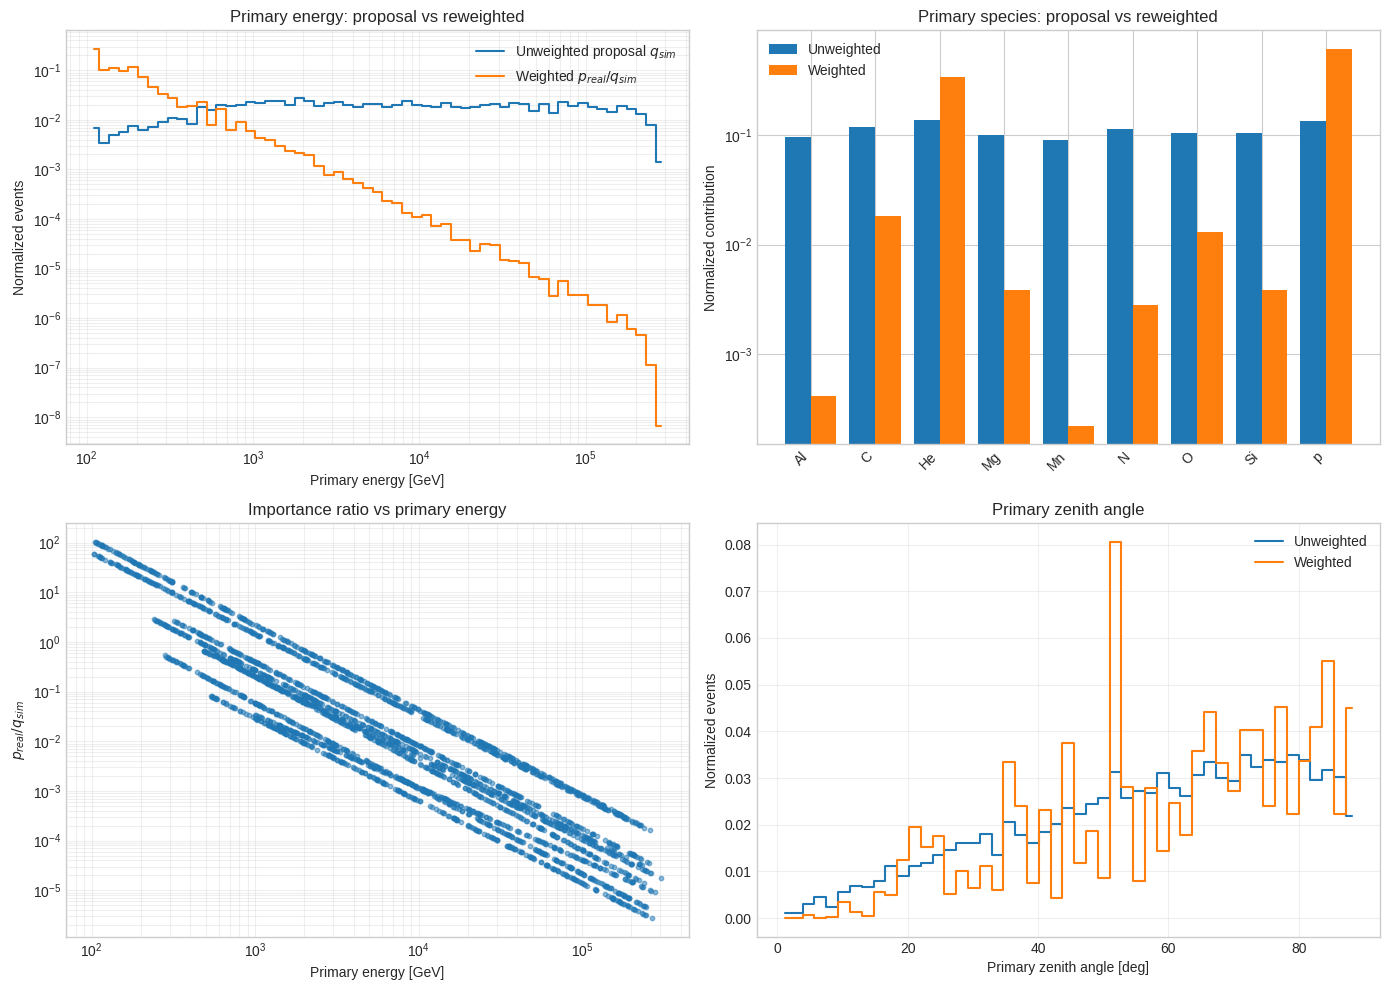

In [12]:
IMPORTANCE_MAX_EVENTS = None
IMPORTANCE_WEIGHT_COLUMN = "importance_ratio"


def effective_sample_size(weights: np.ndarray) -> float:
    """Return the importance-weight effective sample size."""
    weights = np.asarray(weights, dtype=float)
    weights = weights[np.isfinite(weights) & (weights > 0)]
    if weights.size == 0:
        return 0.0
    return float(weights.sum() ** 2 / np.sum(weights ** 2))


def normalized_hist(values: np.ndarray, bins: np.ndarray, weights: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Return a histogram normalized to unit area in bin-count space."""
    counts, edges = np.histogram(values, bins=bins, weights=weights)
    total = counts.sum()
    if total > 0:
        counts = counts / total
    return counts, edges


def prepare_importance_primary_table(manifest: pd.DataFrame, max_events: int | None = IMPORTANCE_MAX_EVENTS) -> pd.DataFrame:
    """Return successful manifest rows with primary metadata and valid importance weights."""
    successful = manifest.drop_duplicates("event_id", keep="last")
    successful = successful[successful["status"].isin(["done", "skipped_done"])].copy()
    if max_events is not None:
        successful = successful.head(max_events).copy()
    if "primary_mnemonic" not in successful.columns or "E0_GeV" not in successful.columns:
        successful = load_primary_metadata_for_manifest(successful, CONFIG.output_root)
    if IMPORTANCE_WEIGHT_COLUMN not in successful.columns:
        raise KeyError(f"Column {IMPORTANCE_WEIGHT_COLUMN!r} is required for importance-sampling diagnostics.")
    successful[IMPORTANCE_WEIGHT_COLUMN] = pd.to_numeric(successful[IMPORTANCE_WEIGHT_COLUMN], errors="coerce")
    successful = successful[np.isfinite(successful[IMPORTANCE_WEIGHT_COLUMN]) & (successful[IMPORTANCE_WEIGHT_COLUMN] > 0)].copy()
    return successful


importance_primaries = prepare_importance_primary_table(manifest, IMPORTANCE_MAX_EVENTS)
weights = importance_primaries[IMPORTANCE_WEIGHT_COLUMN].to_numpy(dtype=float)

print("Primary importance-sampling diagnostics")
print("-" * 72)
print(f"Successful events used : {len(importance_primaries):,}")
print(f"Weight column          : {IMPORTANCE_WEIGHT_COLUMN}")
print(f"Weight min / median / max: {weights.min():.6e} / {np.median(weights):.6e} / {weights.max():.6e}")
print(f"N_eff                  : {effective_sample_size(weights):,.2f}")
print(f"N_eff / N              : {effective_sample_size(weights) / max(len(weights), 1):.6f}")
display(importance_primaries[["event_id", "primary_mnemonic", "E0_GeV", "theta0_deg", "p_real", "q_sim", "importance_ratio", "primary_weight"]].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

energy = importance_primaries.loc[importance_primaries["E0_GeV"] > 0, "E0_GeV"].to_numpy(dtype=float)
energy_weights = importance_primaries.loc[importance_primaries["E0_GeV"] > 0, IMPORTANCE_WEIGHT_COLUMN].to_numpy(dtype=float)
energy_bins = np.logspace(np.log10(energy.min()), np.log10(energy.max()), 60)
energy_unweighted, energy_edges = normalized_hist(energy, energy_bins)
energy_weighted, _ = normalized_hist(energy, energy_bins, weights=energy_weights)
energy_centers = np.sqrt(energy_edges[:-1] * energy_edges[1:])
axes[0, 0].step(energy_centers, energy_unweighted, where="mid", label="Unweighted proposal $q_{sim}$")
axes[0, 0].step(energy_centers, energy_weighted, where="mid", label="Weighted $p_{real}/q_{sim}$")
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Primary energy [GeV]")
axes[0, 0].set_ylabel("Normalized events")
axes[0, 0].set_title("Primary energy: proposal vs reweighted")
axes[0, 0].legend()
axes[0, 0].grid(True, which="both", alpha=0.3)

species_col = "primary_mnemonic" if "primary_mnemonic" in importance_primaries.columns else "corsika_id"
species_labels = sorted(importance_primaries[species_col].fillna("unknown").astype(str).unique())
x = np.arange(len(species_labels))
species_unweighted = importance_primaries[species_col].fillna("unknown").astype(str).value_counts(normalize=True)
species_weighted_raw = importance_primaries.groupby(importance_primaries[species_col].fillna("unknown").astype(str))[IMPORTANCE_WEIGHT_COLUMN].sum()
species_weighted = species_weighted_raw / species_weighted_raw.sum()
axes[0, 1].bar(x - 0.2, [species_unweighted.get(label, 0.0) for label in species_labels], width=0.4, label="Unweighted")
axes[0, 1].bar(x + 0.2, [species_weighted.get(label, 0.0) for label in species_labels], width=0.4, label="Weighted")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(species_labels, rotation=45, ha="right")
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("Normalized contribution")
axes[0, 1].set_title("Primary species: proposal vs reweighted")
axes[0, 1].legend()

axes[1, 0].scatter(importance_primaries["E0_GeV"], importance_primaries[IMPORTANCE_WEIGHT_COLUMN], s=10, alpha=0.5)
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("Primary energy [GeV]")
axes[1, 0].set_ylabel(r"$p_{real}/q_{sim}$")
axes[1, 0].set_title("Importance ratio vs primary energy")
axes[1, 0].grid(True, which="both", alpha=0.3)

theta = importance_primaries["theta0_deg"].dropna().to_numpy(dtype=float)
theta_weights = importance_primaries.loc[importance_primaries["theta0_deg"].notna(), IMPORTANCE_WEIGHT_COLUMN].to_numpy(dtype=float)
theta_bins = np.linspace(theta.min(), theta.max(), 50)
theta_unweighted, theta_edges = normalized_hist(theta, theta_bins)
theta_weighted, _ = normalized_hist(theta, theta_bins, weights=theta_weights)
theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
axes[1, 1].step(theta_centers, theta_unweighted, where="mid", label="Unweighted")
axes[1, 1].step(theta_centers, theta_weighted, where="mid", label="Weighted")
axes[1, 1].set_xlabel("Primary zenith angle [deg]")
axes[1, 1].set_ylabel("Normalized events")
axes[1, 1].set_title("Primary zenith angle")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.2 Neutrino-Level Reweighting

This subsection propagates each primary `importance_ratio` to the neutrinos produced by that event and compares unweighted versus weighted neutrino distributions in $E_\nu$, production height, emission angle, and flavor. These plots show how much the balanced primary proposal changes the apparent neutrino production sample.


In [13]:
IMPORTANCE_MAX_NEUTRINO_EVENTS = None

def load_weighted_neutrino_rows(event_table: pd.DataFrame, max_events: int | None = IMPORTANCE_MAX_NEUTRINO_EVENTS) -> pd.DataFrame:
    """Load TPEANUTS neutrino rows and attach primary importance weights and metadata."""
    rows = []
    selected_events = event_table.copy()
    if max_events is not None:
        selected_events = selected_events.head(max_events).copy()
    for event in selected_events.itertuples(index=False):
        event_dir = path_from_output(event.output_dir)
        neutrinos = load_tpeanuts_neutrinos(event_dir)
        if neutrinos.empty:
            continue
        neutrinos = neutrinos.copy()
        neutrinos["event_id"] = int(event.event_id)
        neutrinos["primary_mnemonic"] = getattr(event, "primary_mnemonic", "unknown")
        neutrinos["E0_GeV"] = float(getattr(event, "E0_GeV", np.nan))
        neutrinos["theta0_deg"] = float(getattr(event, "theta0_deg", np.nan))
        neutrinos["primary_weight"] = float(getattr(event, "primary_weight", np.nan))
        neutrinos["p_real"] = float(getattr(event, "p_real", np.nan))
        neutrinos["q_sim"] = float(getattr(event, "q_sim", np.nan))
        neutrinos["importance_ratio"] = float(getattr(event, "importance_ratio", np.nan))
        rows.append(neutrinos)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


weighted_neutrinos = load_weighted_neutrino_rows(importance_primaries, IMPORTANCE_MAX_NEUTRINO_EVENTS)

Neutrino importance-sampling diagnostics
------------------------------------------------------------------------
Events scanned     : 2,870
Neutrino rows loaded: 9,599,950
Neutrino-row N_eff : 8,652.71
N_eff / N          : 0.000901


,shower,production_id,neutrino_id,neutrino_pdg,parent_pdg,parent_corsika_code,parent_A,parent_Z,neutrino_energy_gev,neutrino_kinetic_energy_gev,theta_emission_deg,phi_emission_deg,x_production_m,y_production_m,z_production_m,h_production_m,nx_emission,ny_emission,nz_emission,time_production_s,neutrino_weight,slant_depth_g_cm2,parent_energy_gev,parent_kinetic_energy_gev,parent_theta_deg,parent_h_m,parent_weight,event_id,primary_mnemonic,E0_GeV,theta0_deg,primary_weight,p_real,q_sim,importance_ratio
0,0,6582,0,14,211,21,0,1,5.922820,5.922820,9.283531,-155.585220,3791.505859,1640.702637,6396444.0,25445.095703,-0.147475,-0.066943,-0.986798,0.000295,1.0,24.332930,21.571608,21.432037,9.015750,25445.095703,1.0,37,Mg,2484.570737,9.620065,0.000002,1.653052e-13,3.588696e-12,0.046063
1,0,6978,1,-14,-211,22,0,-1,1.628941,1.628941,12.142147,-165.171967,1673.526123,494.908630,6383360.5,12360.546875,-0.203591,-0.053898,-0.977571,0.000340,1.0,190.891632,10.203801,10.064231,11.143243,12360.546875,1.0,37,Mg,2484.570737,9.620065,0.000002,1.653052e-13,3.588696e-12,0.046063
2,0,11325,2,14,211,21,0,1,0.077986,0.077986,15.455360,139.960190,1965.425659,569.703064,6384888.5,13888.681641,-0.204154,0.171547,-0.963791,0.000335,1.0,149.753830,0.692629,0.553059,32.644218,13888.681641,1.0,37,Mg,2484.570737,9.620065,0.000002,1.653052e-13,3.588696e-12,0.046063
3,0,11347,3,12,-13,6,0,1,0.063316,0.063316,34.991081,-138.623337,-32.238552,982.124268,6381936.5,10936.824219,-0.430365,-0.379106,-0.819185,0.000347,1.0,245.523911,0.411394,0.305736,34.390148,10936.824219,1.0,37,Mg,2484.570737,9.620065,0.000002,1.653052e-13,3.588696e-12,0.046063
4,0,11347,4,-14,-13,6,0,1,0.170245,0.170245,44.776058,173.029526,-32.238552,982.124268,6381936.5,10936.824219,-0.699115,0.085475,-0.709882,0.000347,1.0,245.523911,0.411394,0.305736,34.390148,10936.824219,1.0,37,Mg,2484.570737,9.620065,0.000002,1.653052e-13,3.588696e-12,0.046063


9969.345703125 3.5653345548780635e-05
9969.346 3.5653346e-05


/tmp/ipykernel_3303/570905224.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()
/tmp/ipykernel_3303/570905224.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend()


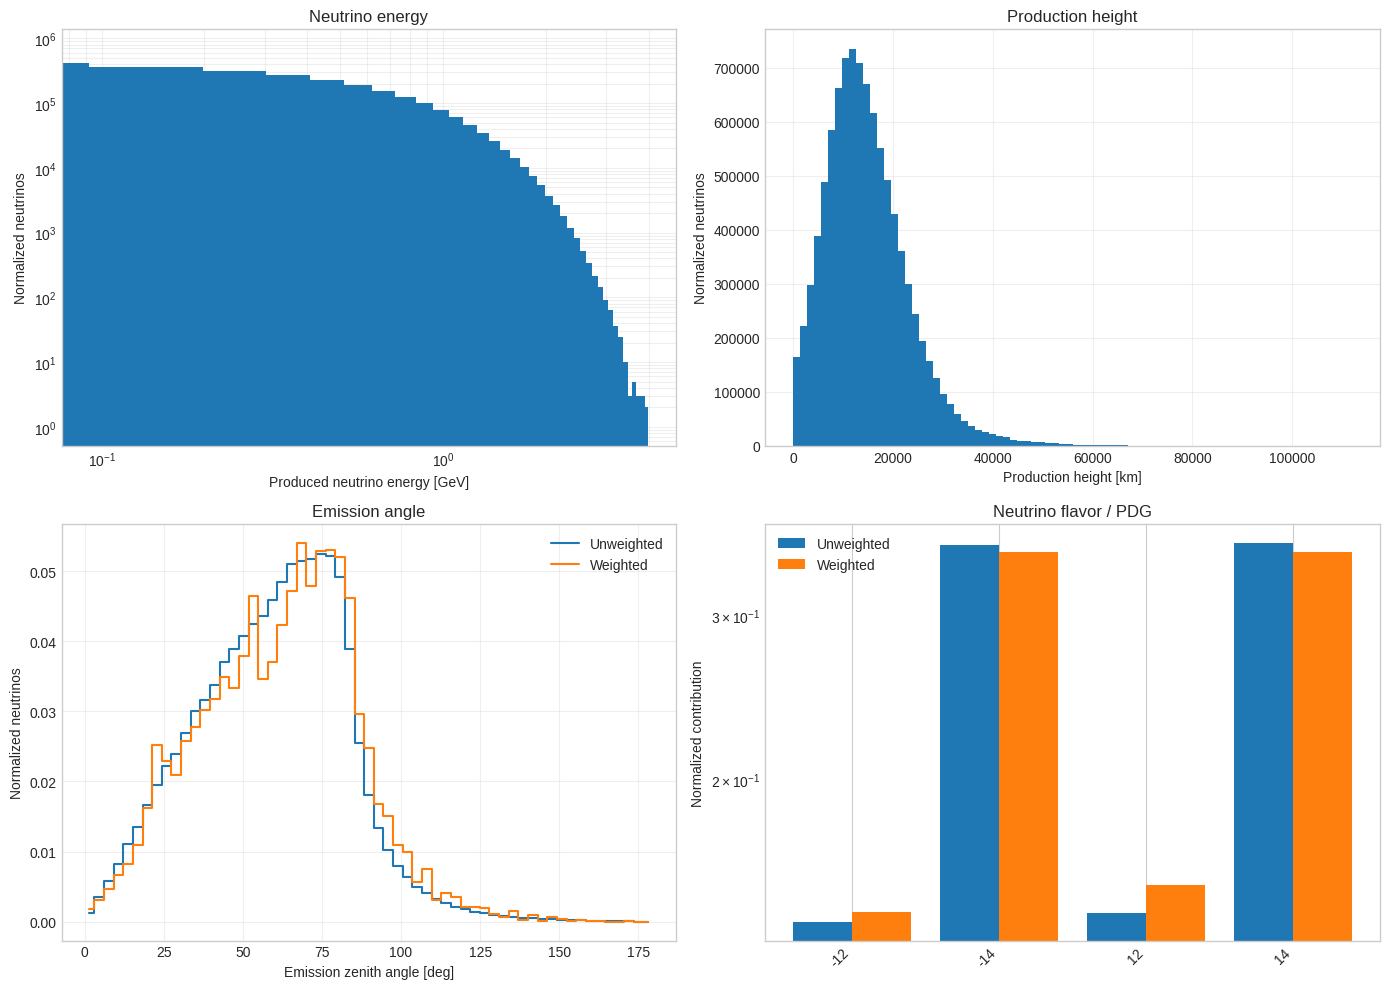

In [14]:

print("Neutrino importance-sampling diagnostics")
print("-" * 72)
if IMPORTANCE_MAX_NEUTRINO_EVENTS is None:
    max_scanned_events = len(importance_primaries)
else:
    max_scanned_events = IMPORTANCE_MAX_NEUTRINO_EVENTS
print(f"Events scanned     : {min(len(importance_primaries), max_scanned_events):,}")
print(f"Neutrino rows loaded: {len(weighted_neutrinos):,}")

if weighted_neutrinos.empty:
    print("No TPEANUTS neutrino-production rows were found for the selected events.")
else:
    weighted_neutrinos = weighted_neutrinos[np.isfinite(weighted_neutrinos["importance_ratio"]) & (weighted_neutrinos["importance_ratio"] > 0)].copy()
    print(f"Neutrino-row N_eff : {effective_sample_size(weighted_neutrinos['importance_ratio'].to_numpy()):,.2f}")
    print(f"N_eff / N          : {effective_sample_size(weighted_neutrinos['importance_ratio'].to_numpy()) / max(len(weighted_neutrinos), 1):.6f}")
    display(weighted_neutrinos.head())

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    e_col = "neutrino_energy_gev"
    positive = weighted_neutrinos[e_col] > 0
    e_nu = weighted_neutrinos.loc[positive, e_col].to_numpy(dtype=float)
    print(e_nu.max(), e_nu.min())
    print(weighted_neutrinos["neutrino_energy_gev"].max(), weighted_neutrinos["neutrino_energy_gev"].min())
    e_w = weighted_neutrinos.loc[positive, "importance_ratio"].to_numpy(dtype=float)
    e_bins = np.logspace(np.log10(e_nu.min()), np.log10(e_nu.max()), 70)
    e_unweighted, e_edges = normalized_hist(e_nu, e_bins)
    e_weighted, _ = normalized_hist(e_nu, e_bins, weights=e_w)
    e_centers = np.sqrt(e_edges[:-1] * e_edges[1:])
    #axes[0, 0].step(e_centers, e_unweighted, where="mid", label="Unweighted neutrino counts")
    #axes[0, 0].step(e_centers, e_weighted, where="mid", label="Weighted by primary $p/q$")
    axes[0, 0].hist(np.log10(weighted_neutrinos["neutrino_energy_gev"]), bins=80)
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_xlabel("Produced neutrino energy [GeV]")
    axes[0, 0].set_ylabel("Normalized neutrinos")
    axes[0, 0].set_title("Neutrino energy")
    axes[0, 0].legend()
    axes[0, 0].grid(True, which="both", alpha=0.3)

    h = weighted_neutrinos["h_production_m"].dropna().to_numpy(dtype=float)
    h_w = weighted_neutrinos.loc[weighted_neutrinos["h_production_m"].notna(), "importance_ratio"].to_numpy(dtype=float)
    h_bins = np.linspace(h.min(), h.max(), 60)
    h_unweighted, h_edges = normalized_hist(h, h_bins)
    h_weighted, _ = normalized_hist(h, h_bins, weights=h_w)
    h_centers = 0.5 * (h_edges[:-1] + h_edges[1:])
    #axes[0, 1].step(h_centers / 1000.0, h_unweighted, where="mid", label="Unweighted")
    #axes[0, 1].step(h_centers / 1000.0, h_weighted, where="mid", label="Weighted")
    axes[0, 1].hist(h, bins=80)
    axes[0, 1].set_xlabel("Production height [km]")
    axes[0, 1].set_ylabel("Normalized neutrinos")
    axes[0, 1].set_title("Production height")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    theta = weighted_neutrinos["theta_emission_deg"].dropna().to_numpy(dtype=float)
    theta_w = weighted_neutrinos.loc[weighted_neutrinos["theta_emission_deg"].notna(), "importance_ratio"].to_numpy(dtype=float)
    theta_bins = np.linspace(theta.min(), theta.max(), 60)
    theta_unweighted, theta_edges = normalized_hist(theta, theta_bins)
    theta_weighted, _ = normalized_hist(theta, theta_bins, weights=theta_w)
    theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
    axes[1, 0].step(theta_centers, theta_unweighted, where="mid", label="Unweighted")
    axes[1, 0].step(theta_centers, theta_weighted, where="mid", label="Weighted")
    axes[1, 0].set_xlabel("Emission zenith angle [deg]")
    axes[1, 0].set_ylabel("Normalized neutrinos")
    axes[1, 0].set_title("Emission angle")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    flavor_col = "flavor" if "flavor" in weighted_neutrinos.columns else "neutrino_pdg"
    flavor_labels = sorted(weighted_neutrinos[flavor_col].fillna("unknown").astype(str).unique())
    x = np.arange(len(flavor_labels))
    flavor_unweighted = weighted_neutrinos[flavor_col].fillna("unknown").astype(str).value_counts(normalize=True)
    flavor_weighted_raw = weighted_neutrinos.groupby(weighted_neutrinos[flavor_col].fillna("unknown").astype(str))["importance_ratio"].sum()
    flavor_weighted = flavor_weighted_raw / flavor_weighted_raw.sum()
    axes[1, 1].bar(x - 0.2, [flavor_unweighted.get(label, 0.0) for label in flavor_labels], width=0.4, label="Unweighted")
    axes[1, 1].bar(x + 0.2, [flavor_weighted.get(label, 0.0) for label in flavor_labels], width=0.4, label="Weighted")
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(flavor_labels, rotation=45, ha="right")
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_ylabel("Normalized contribution")
    axes[1, 1].set_title("Neutrino flavor / PDG")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


### 4.3 Statistical Robustness Checks

This subsection checks whether the weighted neutrino distributions are statistically robust or dominated by a small number of high-weight primaries. It computes `sum_weights`, `sum_weights2`, relative uncertainty $\sqrt{\sum w_i^2}/\sum w_i$, and effective sample size per bin for neutrino energy, production height, and emission angle. It also lists the primary events contributing the largest total weighted neutrino yield.


Weighted-neutrino robustness summary
------------------------------------------------------------------------
Rows used                 : 9,599,950
Total sum_weights         : 2.958058e+05
Total sum_weights2        : 1.011256e+07
Global N_eff              : 8,652.71
Global N_eff / N          : 0.000901


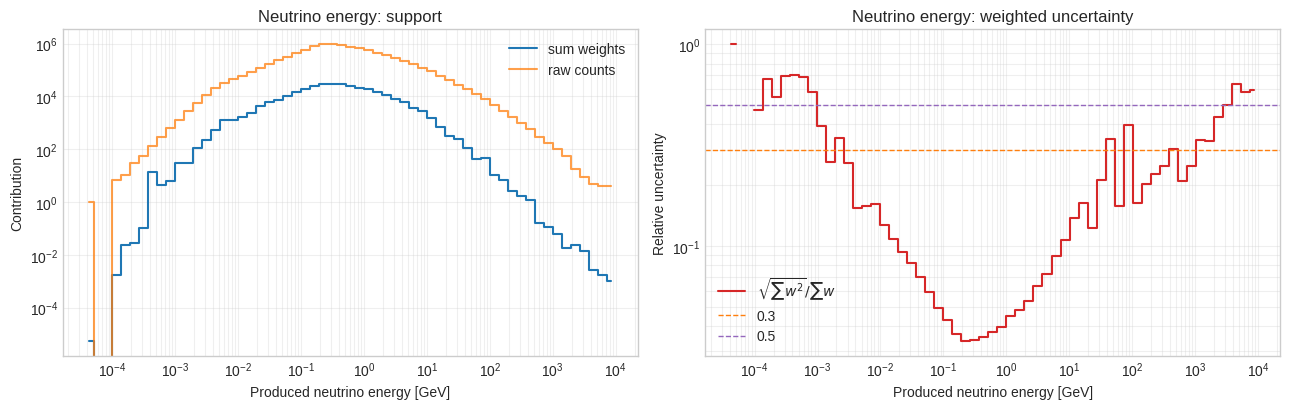

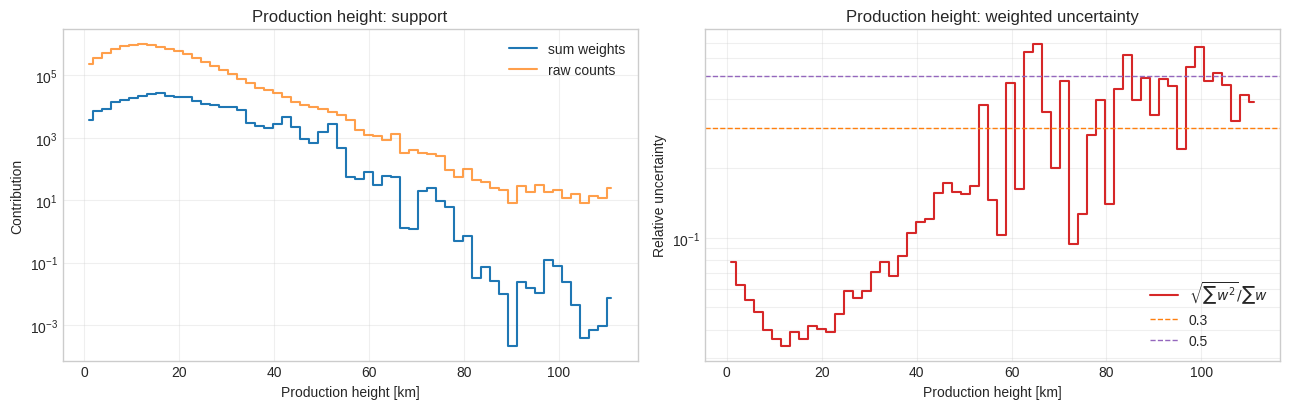

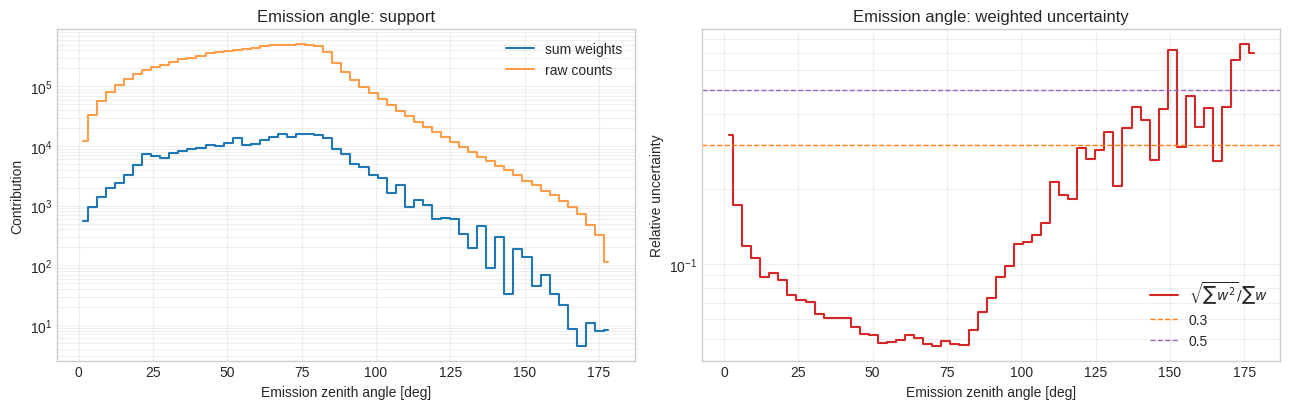

Bins with the largest relative uncertainty in energy


,bin_left,bin_right,bin_center,counts,sum_weights,sum_weights2,relative_uncertainty,n_eff
0,0.000036,0.000050,0.000043,1,0.000005,2.857828e-11,1.000000,1.000000
7,0.000358,0.000498,0.000428,136,13.615230,9.121160e+01,0.701455,2.032356
6,0.000258,0.000358,0.000308,54,0.105593,5.349666e-03,0.692670,2.084236
8,0.000498,0.000693,0.000595,296,4.451138,9.386071e+00,0.688289,2.110854
4,0.000133,0.000185,0.000159,11,0.023186,2.409110e-04,0.669425,2.231499
56,3708.348145,5156.348633,4432.348633,5,0.002575,2.674758e-06,0.635230,2.478210
58,7169.766113,9969.348633,8569.557617,4,0.001008,3.594905e-07,0.594637,2.828109
9,0.000693,0.000963,0.000828,656,6.349239,1.360597e+01,0.580956,2.962879
57,5156.348633,7169.766113,6163.057617,4,0.001654,9.182841e-07,0.579252,2.980335
5,0.000185,0.000258,0.000221,31,0.027598,2.292280e-04,0.548607,3.322590


Bins with the largest relative uncertainty in production height


,bin_left,bin_right,bin_center,counts,sum_weights,sum_weights2,relative_uncertainty,n_eff
34,64.539780,66.438011,65.488892,1307,53.571712,1.356211e+03,0.687429,2.116137
52,98.707878,100.606102,99.656990,22,0.080226,2.860107e-03,0.666619,2.250322
33,62.641552,64.539780,63.590668,873,57.558713,1.356687e+03,0.639925,2.441981
44,83.522057,85.420280,84.471169,38,0.070732,1.930239e-03,0.621143,2.591890
51,96.809647,98.707878,97.758759,19,0.119583,4.290700e-03,0.547766,3.332805
54,102.504326,104.402557,103.453445,16,0.004439,5.256385e-06,0.516474,3.748893
46,87.318504,89.216736,88.267624,22,0.010063,2.429448e-05,0.489789,4.168512
48,91.114960,93.013191,92.064072,28,0.023556,1.302846e-04,0.484552,4.259109
37,70.234459,72.132690,71.183578,338,19.299913,8.469182e+01,0.476832,4.398142
53,100.606102,102.504326,101.555214,12,0.024039,1.302958e-04,0.474838,4.435151


Top 20 primary events by weighted neutrino contribution


,event_id,neutrino_rows,weighted_neutrino_sum,mean_importance_ratio,primary_mnemonic,E0_GeV,theta0_deg,weighted_fraction
1332,4552,84,6326.373352,75.313968,p,126.553770,80.417085,0.021387
2034,7030,65,5774.802567,88.843116,p,115.008988,24.385914,0.019522
238,740,78,5737.469431,73.557300,p,128.866122,72.832245,0.019396
1627,5539,59,5119.482297,86.770886,p,117.409388,66.060571,0.017307
1028,3502,53,5054.159050,95.361492,p,110.341706,88.590296,0.017086
1794,6119,45,4606.115244,102.358117,p,106.127321,76.595447,0.015571
362,1157,45,4498.679455,99.970655,p,107.274864,37.593376,0.015208
240,743,48,3972.974437,82.770301,p,120.406871,83.221697,0.013431
819,2730,70,3971.701205,56.738589,p,151.201806,21.399427,0.013427
2027,7008,49,3961.146120,80.839717,p,122.114886,51.636943,0.013391


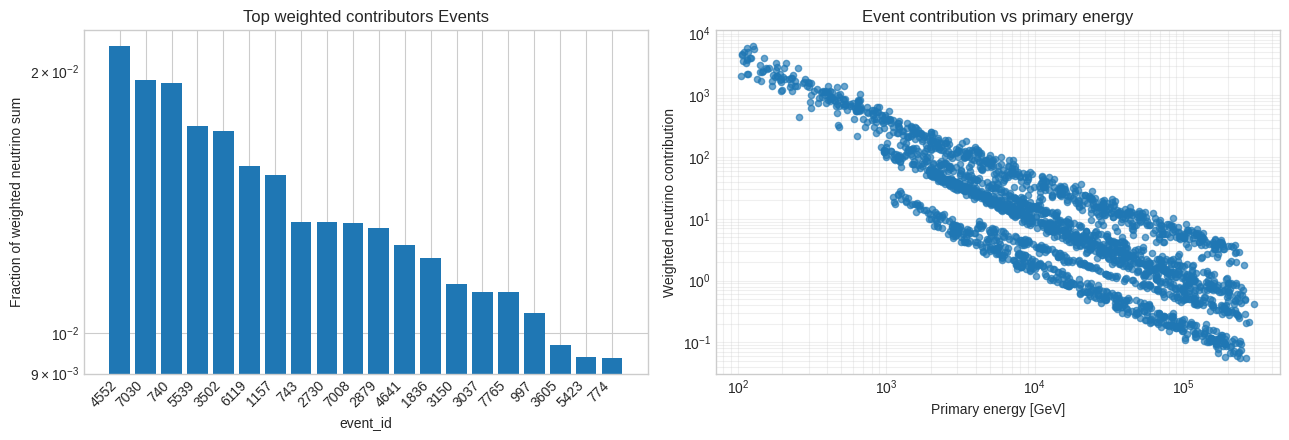

In [15]:
ROBUSTNESS_MIN_SUM_WEIGHTS = 0.0
ROBUSTNESS_TOP_EVENTS = 20


def weighted_bin_stats(values: np.ndarray, weights: np.ndarray, bins: np.ndarray) -> pd.DataFrame:
    """Return weighted sums, uncertainty, and effective sample size per bin."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]

    counts, edges = np.histogram(values, bins=bins)
    sum_w, _ = np.histogram(values, bins=bins, weights=weights)
    sum_w2, _ = np.histogram(values, bins=bins, weights=weights**2)
    centers = 0.5 * (edges[:-1] + edges[1:])

    rel_unc = np.divide(np.sqrt(sum_w2), sum_w, out=np.full_like(sum_w, np.nan, dtype=float), where=sum_w > 0)
    n_eff = np.divide(sum_w**2, sum_w2, out=np.zeros_like(sum_w, dtype=float), where=sum_w2 > 0)

    return pd.DataFrame(
        {
            "bin_left": edges[:-1],
            "bin_right": edges[1:],
            "bin_center": centers,
            "counts": counts,
            "sum_weights": sum_w,
            "sum_weights2": sum_w2,
            "relative_uncertainty": rel_unc,
            "n_eff": n_eff,
        }
    )


def plot_weighted_robustness(stats: pd.DataFrame, x_label: str, title: str, *, logx: bool = False) -> None:
    """Plot weighted contribution and relative uncertainty for one binned variable."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    x = stats["bin_center"].to_numpy(dtype=float)

    axes[0].step(x, stats["sum_weights"], where="mid", label="sum weights")
    axes[0].step(x, stats["counts"], where="mid", label="raw counts", alpha=0.75)
    axes[0].set_ylabel("Contribution")
    axes[0].set_title(f"{title}: support")
    axes[0].legend()
    axes[0].grid(True, which="both", alpha=0.3)

    axes[1].step(x, stats["relative_uncertainty"], where="mid", color="tab:red", label=r"$\sqrt{\sum w^2}/\sum w$")
    axes[1].axhline(0.3, color="tab:orange", linestyle="--", lw=1.0, label="0.3")
    axes[1].axhline(0.5, color="tab:purple", linestyle="--", lw=1.0, label="0.5")
    axes[1].set_ylabel("Relative uncertainty")
    axes[1].set_title(f"{title}: weighted uncertainty")
    axes[1].legend()
    axes[1].grid(True, which="both", alpha=0.3)

    for ax in axes:
        ax.set_xlabel(x_label)
        if logx:
            ax.set_xscale("log")
        ax.set_yscale("log")

    plt.tight_layout()
    plt.show()


if "weighted_neutrinos" not in globals() or weighted_neutrinos.empty:
    print("Run subsection 4.2 first to load weighted_neutrinos.")
else:
    robust_neutrinos = weighted_neutrinos.copy()
    robust_neutrinos = robust_neutrinos[np.isfinite(robust_neutrinos["importance_ratio"]) & (robust_neutrinos["importance_ratio"] > 0)].copy()

    print("Weighted-neutrino robustness summary")
    print("-" * 72)
    print(f"Rows used                 : {len(robust_neutrinos):,}")
    print(f"Total sum_weights         : {robust_neutrinos['importance_ratio'].sum():.6e}")
    print(f"Total sum_weights2        : {(robust_neutrinos['importance_ratio'] ** 2).sum():.6e}")
    print(f"Global N_eff              : {effective_sample_size(robust_neutrinos['importance_ratio'].to_numpy()):,.2f}")
    print(f"Global N_eff / N          : {effective_sample_size(robust_neutrinos['importance_ratio'].to_numpy()) / max(len(robust_neutrinos), 1):.6f}")

    positive_energy = robust_neutrinos.loc[robust_neutrinos["neutrino_energy_gev"] > 0, "neutrino_energy_gev"]
    energy_bins = np.logspace(np.log10(positive_energy.min()), np.log10(positive_energy.max()), 60)
    energy_stats = weighted_bin_stats(
        robust_neutrinos["neutrino_energy_gev"].to_numpy(),
        robust_neutrinos["importance_ratio"].to_numpy(),
        energy_bins,
    )
    plot_weighted_robustness(energy_stats, "Produced neutrino energy [GeV]", "Neutrino energy", logx=True)

    height_bins = np.linspace(robust_neutrinos["h_production_m"].min(), robust_neutrinos["h_production_m"].max(), 60)
    height_stats = weighted_bin_stats(
        robust_neutrinos["h_production_m"].to_numpy() / 1000.0,
        robust_neutrinos["importance_ratio"].to_numpy(),
        height_bins / 1000.0,
    )
    plot_weighted_robustness(height_stats, "Production height [km]", "Production height", logx=False)

    theta_bins = np.linspace(robust_neutrinos["theta_emission_deg"].min(), robust_neutrinos["theta_emission_deg"].max(), 60)
    theta_stats = weighted_bin_stats(
        robust_neutrinos["theta_emission_deg"].to_numpy(),
        robust_neutrinos["importance_ratio"].to_numpy(),
        theta_bins,
    )
    plot_weighted_robustness(theta_stats, "Emission zenith angle [deg]", "Emission angle", logx=False)

    print("Bins with the largest relative uncertainty in energy")
    display(
        energy_stats[energy_stats["sum_weights"] > ROBUSTNESS_MIN_SUM_WEIGHTS]
        .sort_values("relative_uncertainty", ascending=False)
        .head(15)
    )

    print("Bins with the largest relative uncertainty in production height")
    display(
        height_stats[height_stats["sum_weights"] > ROBUSTNESS_MIN_SUM_WEIGHTS]
        .sort_values("relative_uncertainty", ascending=False)
        .head(15)
    )

    event_contribution = (
        robust_neutrinos.groupby("event_id")
        .agg(
            neutrino_rows=("event_id", "size"),
            weighted_neutrino_sum=("importance_ratio", "sum"),
            mean_importance_ratio=("importance_ratio", "mean"),
            primary_mnemonic=("primary_mnemonic", "first"),
            E0_GeV=("E0_GeV", "first"),
            theta0_deg=("theta0_deg", "first"),
        )
        .reset_index()
    )
    event_contribution["weighted_fraction"] = event_contribution["weighted_neutrino_sum"] / event_contribution["weighted_neutrino_sum"].sum()
    event_contribution = event_contribution.sort_values("weighted_neutrino_sum", ascending=False)

    print(f"Top {ROBUSTNESS_TOP_EVENTS} primary events by weighted neutrino contribution")
    display(event_contribution.head(ROBUSTNESS_TOP_EVENTS))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    top = event_contribution.head(ROBUSTNESS_TOP_EVENTS).copy()
    labels = top["event_id"].astype(str)
    axes[0].bar(np.arange(len(top)), top["weighted_fraction"])
    axes[0].set_xticks(np.arange(len(top)))
    axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("event_id")
    axes[0].set_ylabel("Fraction of weighted neutrino sum")
    axes[0].set_title("Top weighted contributors Events")

    axes[1].scatter(event_contribution["E0_GeV"], event_contribution["weighted_neutrino_sum"], s=20, alpha=0.65)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Primary energy [GeV]")
    axes[1].set_ylabel("Weighted neutrino contribution")
    axes[1].set_title("Event contribution vs primary energy")
    axes[1].grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()


### 4.4 Weighted and Unweighted Cube Slices

This subsection builds two coarse cubes in $E_\nu$, $\theta_{emission}$, and $h_{production}$: one with raw Monte Carlo counts and one weighted by `importance_ratio`. A fixed height slice is shown side by side to reveal how the sampling correction changes the learned target distribution.


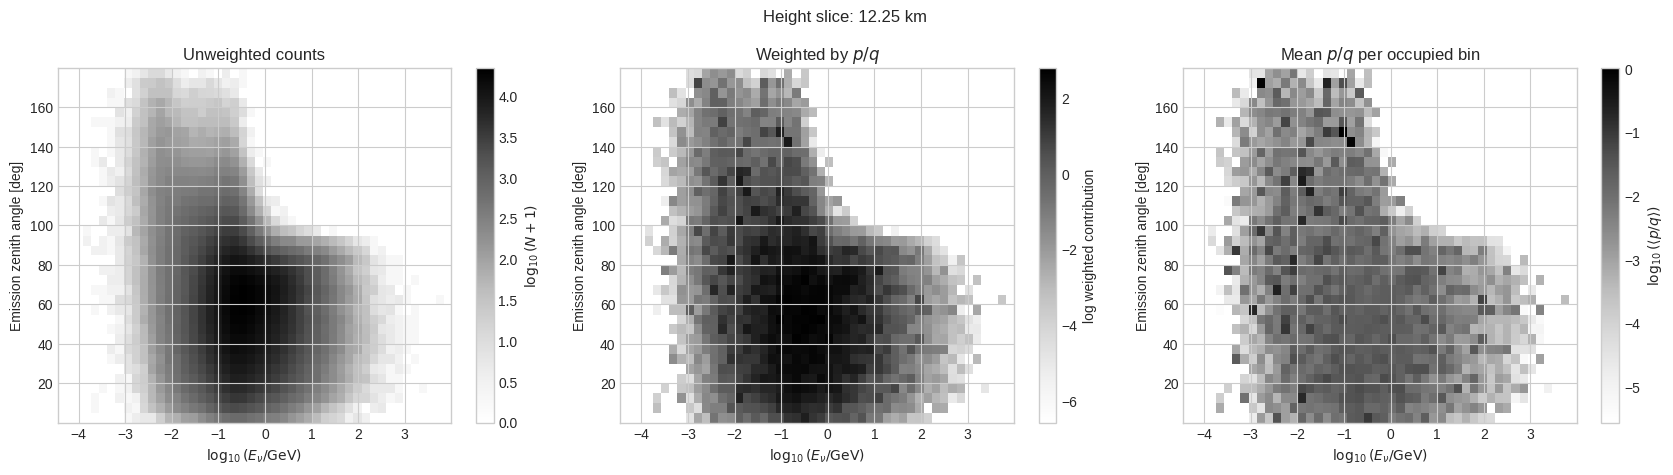

Cube summary
------------------------------------------------------------------------
cube_counts shape   : (48, 36, 32)
unweighted sum      : 9.599950e+06
weighted sum        : 2.958058e+05
height slice index  : 3
height slice center : 12.250 km


In [16]:
CUBE_N_LOGE = 48
CUBE_N_THETA = 36
CUBE_N_H = 32
CUBE_HEIGHT_SLICE_INDEX = None


def build_neutrino_importance_cubes(neutrinos: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
    """Build unweighted and importance-weighted neutrino cubes."""
    required = ["neutrino_energy_gev", "theta_emission_deg", "h_production_m", "importance_ratio"]
    missing = [col for col in required if col not in neutrinos.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    data = neutrinos.dropna(subset=required).copy()
    data = data[(data["neutrino_energy_gev"] > 0) & (data["importance_ratio"] > 0)].copy()
    loge = np.log10(data["neutrino_energy_gev"].to_numpy(dtype=float))
    theta = data["theta_emission_deg"].to_numpy(dtype=float)
    h = data["h_production_m"].to_numpy(dtype=float)
    weights = data["importance_ratio"].to_numpy(dtype=float)

    edges = [
        np.linspace(loge.min(), loge.max(), CUBE_N_LOGE + 1),
        np.linspace(theta.min(), theta.max(), CUBE_N_THETA + 1),
        np.linspace(h.min(), h.max(), CUBE_N_H + 1),
    ]
    points = np.column_stack([loge, theta, h])
    cube_counts, _ = np.histogramdd(points, bins=edges)
    cube_weighted, _ = np.histogramdd(points, bins=edges, weights=weights)
    return cube_counts, cube_weighted, edges


if "weighted_neutrinos" not in globals() or weighted_neutrinos.empty:
    print("Run subsection 4.2 first to load weighted_neutrinos.")
else:
    cube_counts, cube_weighted, cube_edges = build_neutrino_importance_cubes(weighted_neutrinos)
    h_edges = cube_edges[2]
    h_centers = 0.5 * (h_edges[:-1] + h_edges[1:])
    h_slice = CUBE_HEIGHT_SLICE_INDEX
    if h_slice is None:
        h_slice = int(np.argmax(cube_counts.sum(axis=(0, 1))))

    loge_edges, theta_edges, _ = cube_edges
    extent = [loge_edges[0], loge_edges[-1], theta_edges[0], theta_edges[-1]]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    im0 = axes[0].imshow(
        np.log10(cube_counts[:, :, h_slice].T + 1.0),
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
    )
    axes[0].set_xlabel(r"$\log_{10}(E_\nu / \mathrm{GeV})$")
    axes[0].set_ylabel("Emission zenith angle [deg]")
    axes[0].set_title("Unweighted counts")
    fig.colorbar(im0, ax=axes[0], label=r"$\log_{10}(N+1)$")

    positive_weighted = cube_weighted[cube_weighted > 0]
    weighted_floor = positive_weighted.min() * 0.1 if positive_weighted.size else 1e-30
    im1 = axes[1].imshow(
        np.log10(cube_weighted[:, :, h_slice].T + weighted_floor),
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
    )
    axes[1].set_xlabel(r"$\log_{10}(E_\nu / \mathrm{GeV})$")
    axes[1].set_ylabel("Emission zenith angle [deg]")
    axes[1].set_title("Weighted by $p/q$")
    fig.colorbar(im1, ax=axes[1], label="log weighted contribution")

    ratio = np.divide(cube_weighted, cube_counts, out=np.full_like(cube_weighted, np.nan), where=cube_counts > 0)
    im2 = axes[2].imshow(
        np.log10(ratio[:, :, h_slice].T),
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
    )
    axes[2].set_xlabel(r"$\log_{10}(E_\nu / \mathrm{GeV})$")
    axes[2].set_ylabel("Emission zenith angle [deg]")
    axes[2].set_title("Mean $p/q$ per occupied bin")
    fig.colorbar(im2, ax=axes[2], label=r"$\log_{10}(\langle p/q \rangle)$")

    fig.suptitle(f"Height slice: {h_centers[h_slice] / 1000:.2f} km")
    plt.tight_layout()
    plt.show()

    print("Cube summary")
    print("-" * 72)
    print(f"cube_counts shape   : {cube_counts.shape}")
    print(f"unweighted sum      : {cube_counts.sum():.6e}")
    print(f"weighted sum        : {cube_weighted.sum():.6e}")
    print(f"height slice index  : {h_slice}")
    print(f"height slice center : {h_centers[h_slice] / 1000:.3f} km")
